In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Загрузил данных (UCI Adult)
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
           'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
           'hours-per-week', 'native-country', 'income']
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
df = pd.read_csv(url, names=columns, na_values=' ?', skipinitialspace=True)

In [3]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
# Сделал первичный осмотр 
print(df.head())
print(df.info())
print(df.isnull().sum())

   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

In [5]:
# Очистил данные если естть пропуски
df.dropna(inplace=True)

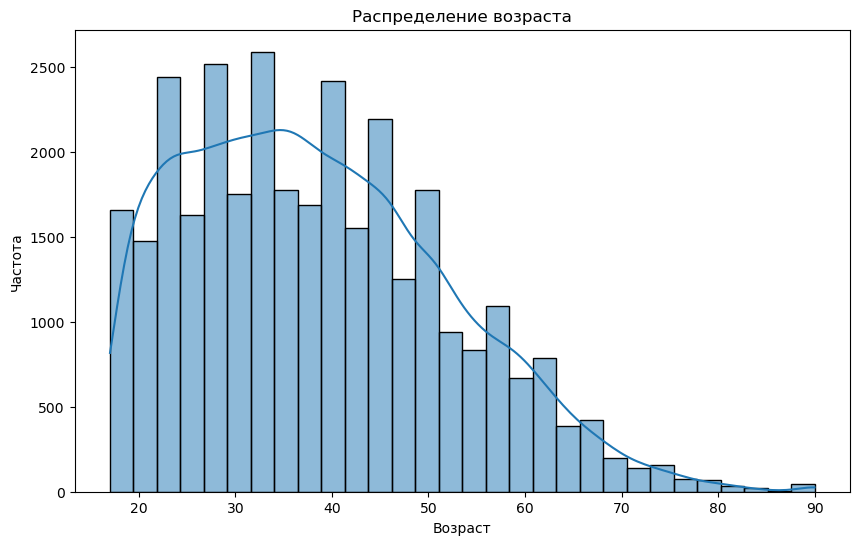

In [6]:
# Провелд разведочный анализ
# Распределение возраста
plt.figure(figsize=(10,6))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Распределение возраста')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.show()

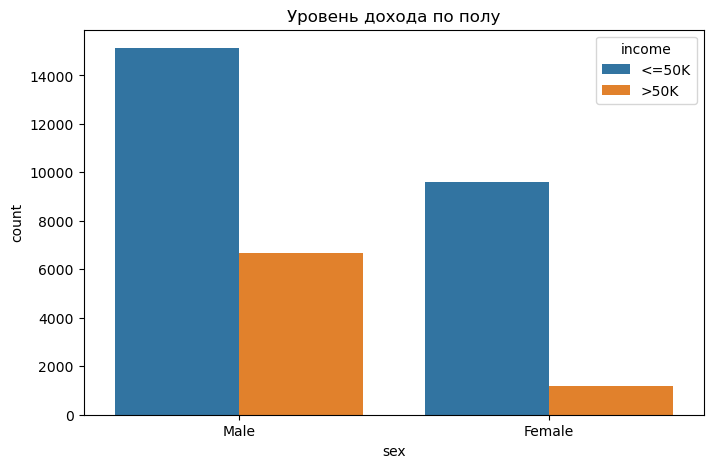

In [7]:
# Доход по полу
plt.figure(figsize=(8,5))
sns.countplot(x='sex', hue='income', data=df)
plt.title('Уровень дохода по полу')
plt.show()

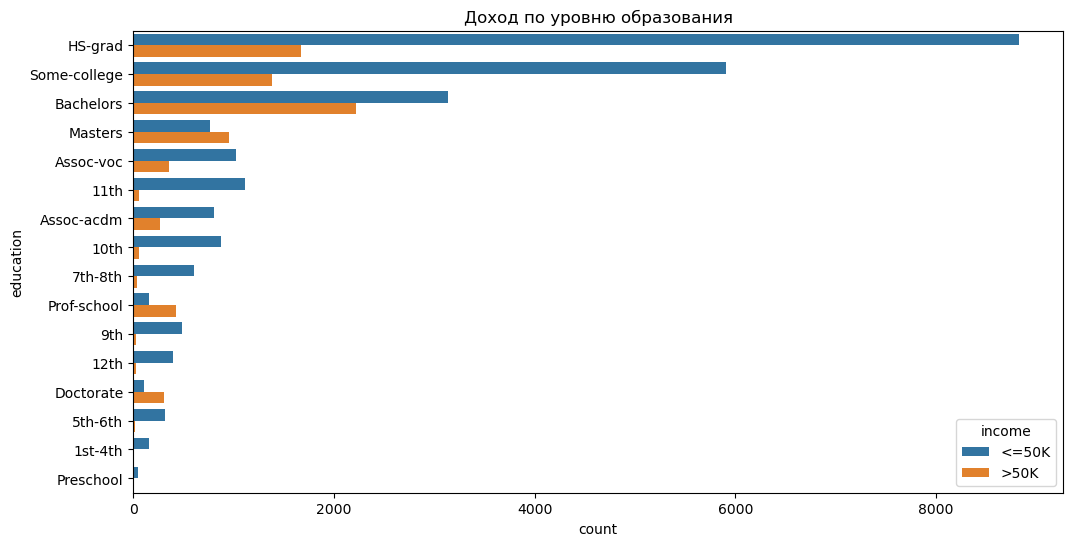

In [8]:
# Зависимость дохода от образования
plt.figure(figsize=(12,6))
sns.countplot(y='education', hue='income', data=df, order=df['education'].value_counts().index)
plt.title('Доход по уровню образования')
plt.show()

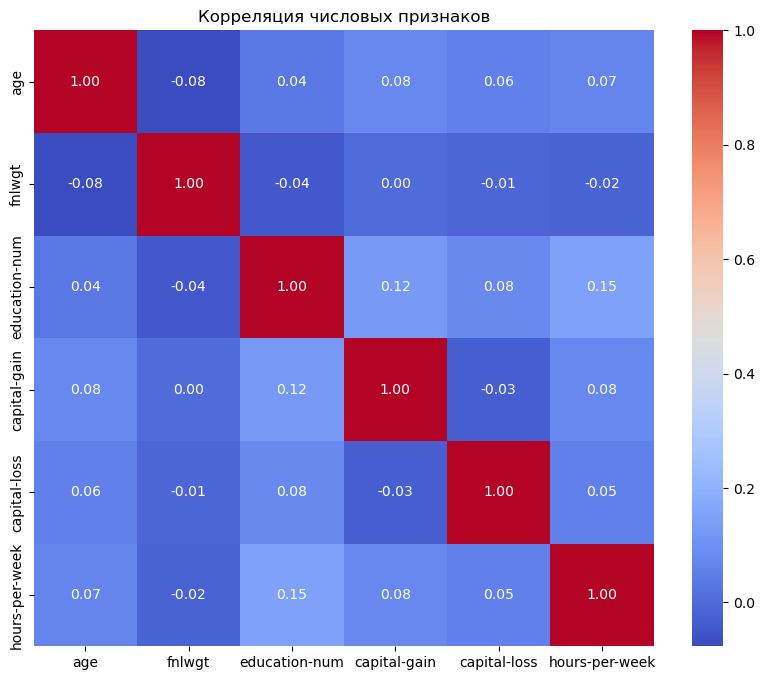

In [9]:
# Тепловая карта корреляций числовых признаков
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция числовых признаков')
plt.show()

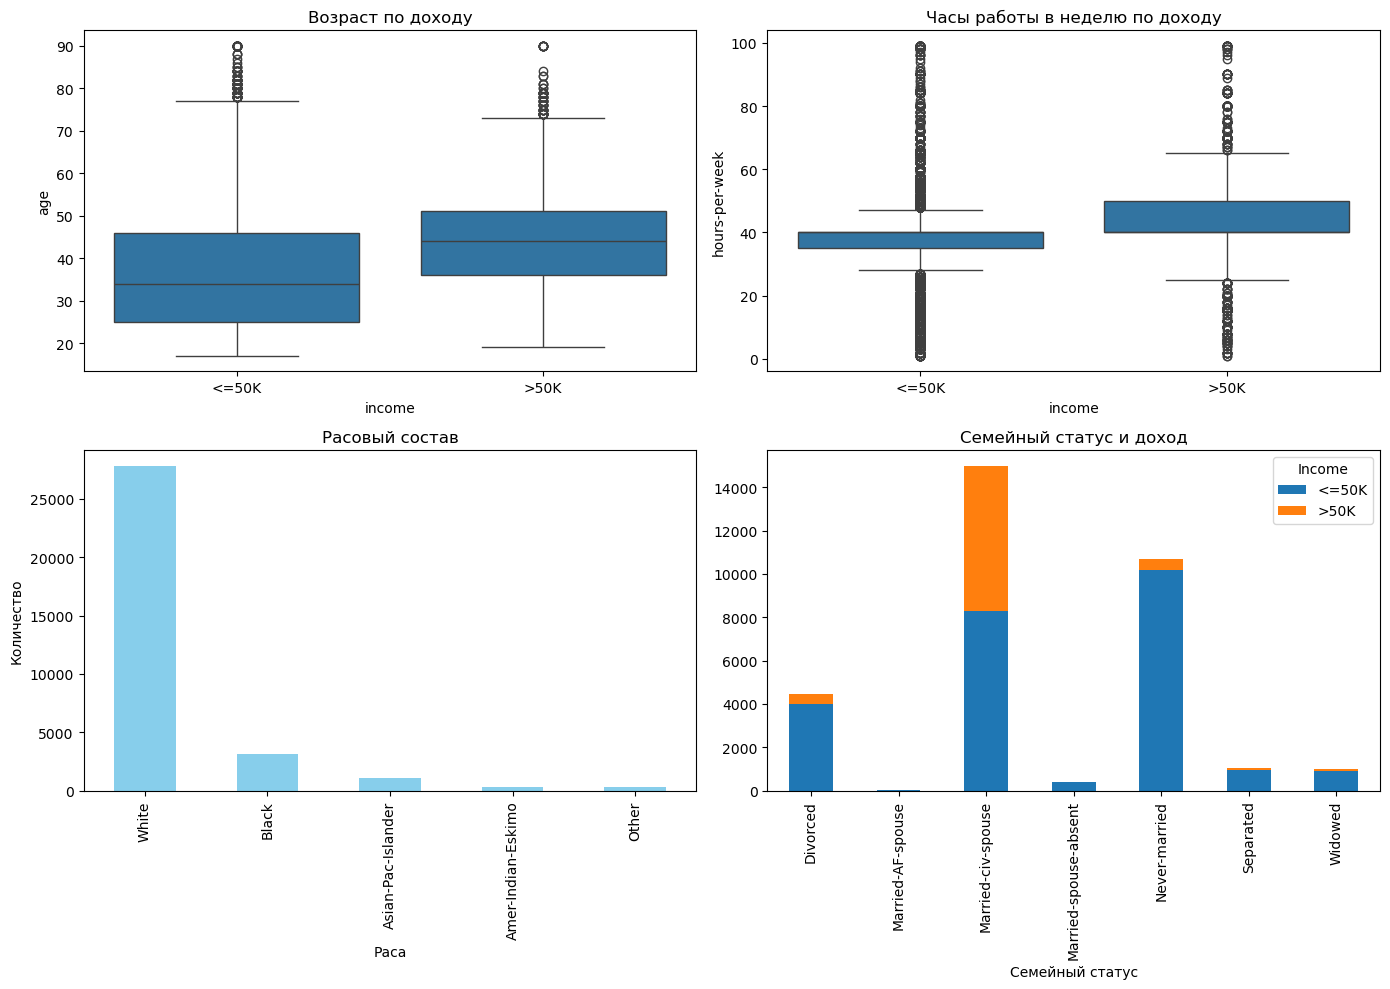

In [16]:
# Создал дашборд
fig, axes = plt.subplots(2, 2, figsize=(14,10))
# График 1: возраст по доходу 
sns.boxplot(x='income', y='age', data=df, ax=axes[0,0])
axes[0,0].set_title('Возраст по доходу')

# График 2: количество рабочих часов по доходу
sns.boxplot(x='income', y='hours-per-week', data=df, ax=axes[0,1])
axes[0,1].set_title('Часы работы в неделю по доходу')

# График 3: распределение рас
df['race'].value_counts().plot(kind='bar', ax=axes[1,0], color='skyblue')
axes[1,0].set_title('Расовый состав')
axes[1,0].set_xlabel('Раса')
axes[1,0].set_ylabel('Количество')

# График 4: семейный статус и доход
pd.crosstab(df['marital-status'], df['income']).plot(kind='bar', stacked=True, ax=axes[1,1])
axes[1,1].set_title('Семейный статус и доход')
axes[1,1].set_xlabel('Семейный статус')
axes[1,1].legend(title='Income')

plt.tight_layout()
plt.show()

In [17]:
# Средний возраст и доход по образованию
pivot = df.pivot_table(index='education', values=['age', 'hours-per-week'], aggfunc='mean')
print(pivot)

                    age  hours-per-week
education                              
10th          37.429796       37.052519
11th          32.355745       33.925957
12th          32.000000       35.780600
1st-4th       46.142857       38.255952
5th-6th       42.885886       38.897898
7th-8th       48.445820       39.366873
9th           41.060311       38.044747
Assoc-acdm    37.381443       40.504217
Assoc-voc     38.553546       41.610709
Bachelors     38.904949       42.614006
Doctorate     47.702179       46.973366
HS-grad       38.974479       40.575374
Masters       44.049913       43.836332
Preschool     42.764706       36.647059
Prof-school   44.746528       47.425347
Some-college  35.756275       38.852284


In [18]:
# Сохраняем дашборд как картинку 
fig.savefig('demographic_dashboard.png')